# Lista 02 de Visão Computacional

Beatriz Rodrigues Cavalcante - 22210505

Hugo Coêlho da Silva - 22111533

Link da lista: https://drive.google.com/file/d/1T3TA4E8gkh4GZb2wwRoXcXnGqmisrElr/view


## Importações e Funções Auxiliares


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
from cv2.typing import MatLike
from pathlib import Path


def show_images(
    *images: np.ndarray,
    titles: list[str] | None = None,
    columns: int = 2,
    scale: int = 5,
) -> None:
    num_images = len(images)

    if titles is None:
        titles = [f"Image {i + 1}" for i in range(num_images)]

    rows = (num_images + columns - 1) // columns

    fig, axes = plt.subplots(rows, columns, figsize=(scale * columns, scale * rows))
    axes = np.array(axes).reshape(rows, columns)

    for ax, img, title in zip(axes.flat, images, titles):
        ax.imshow(img, cmap="gray" if len(img.shape) == 2 else None)
        ax.set_title(title)

    for i in range(num_images, rows * columns):
        fig.delaxes(axes.flat[i])

    plt.tight_layout()

## Questão 1

Nesta questão, foi experimentado três detectores de quinas diferentes: [`Harris Corner Detection`](https://www.datatechnotes.com/2023/07/harris-corner-detection-example-with.html), [`Shi-Thomas Corner Detector`](https://docs.opencv.org/4.5.3/d4/d8c/tutorial_py_shi_tomasi.html) e [`FAST Algorithm`](https://docs.opencv.org/4.5.3/df/d0c/tutorial_py_fast.html).


### Harris Corner Detector

A ideia desse detector é encontrar a variação de intensidade no deslocamento de uma janela centrada num ponto $(u,v)$ em todas as direções, visto que em bordas a variação é forte em apenas uma direção, enquanto em quinas é forte em várias. O fluxo do detector é iniciado pela aplicação, opcional, de uma suavização para diminuir os ruídos; depois, é usado o operador de Sobel para captar as mudanças de intensidade horizontais e verticais em cada pixel; e então, utilizando os gradientes, é analisado a variação da intensidade em vizinhanças locais olhando para os autovalores ($\lambda_1$ e $\lambda_2$), onde temos que:

- $\lambda_1 \approx 0, \lambda_2 \approx 0$ são regiões planas, onde não há mudança significativa em nenhuma direção.
- $\lambda_1 \gg 0, \lambda_2 \approx 0$ são bordas, onde há uma mudança forte em apenas uma direção, mas nenhuma na direção perpendicular.
- $\lambda_1 \gg 0, \lambda_2 \gg 0$ são quinas, onde há mudanças fortes em múltiplas direções.

Então, uma pontuação é atribuída a cada janela para determinar se é uma quina ou não: $$R = \lambda_1\lambda_2 − k(\lambda_1 + \lambda_2)^2$$

No algoritmo, os parâmetros principais são:

- _img_: a imagem a ser analizada em tons de cinza.
- _blockSize_: tamanho da vizinhança.
- _ksize_: tamanho do Sobel para gradiente.
- _k_: sensibilidade do critério Harris.

### Shi-Tomasi Corner Detector (Good Features to Track)

Shi-Tomasi é uma melhoria do Harris Detector. Os autores perceberam que somente quando o $\lambda_1$ e $\lambda_2$ são maiores que um treshold $\lambda_{min}$ é considerado uma quina, então eles propuseram que o cálculo da pontuação fosse simplesmente: $$R = \min(\lambda_1, \lambda_2)$$. E a ideia intuitiva desse método é que se queremos que um ponto seja uma quina, ele precisa ter variações fortes em todas as direções. Isso significa que tanto $\lambda_1$ quanto $\lambda_2$ devem ser grandes. Se o menor deles ($\min$) já for maior que um determinado threshold, então o maior com certeza também é.

No algoritmo, temos os seguintes parâmetros:

- _img_: a imagem a ser analizada em tons de cinza.
- _maxCorners_: máximo de cantos retornados. Se houver mais cantos do que os encontrados, o mais forte deles será retornado. No entanto, se `maxCorners <= 0` implica que nenhum limite máximo foi definido e todos os cantos detectados serão retornados.
- _qualityLevel_: qualidade mínima relativa. O valor do parâmetro é multiplicado pela melhor pontuação, seja ele o menor autovalor ou a resposta da função de Harris. Os cantos com medida de qualidade inferior ao produto são rejeitados. Por exemplo, se o melhor canto tiver medida de qualidade = 1500 e qualityLevel = 0,01, então todos os cantos com medida de qualidade inferior a 15 serão rejeitados.
- _minDistance_: distância mínima entre pontos, para evitar pontos colados.

### FAST Algorithm (Features from Accelerated Segment Test)

Esse algoritmo tem como principio ser, como o nome indica, mais rápido do que preciso, para aplicações em tempo real (drones, robótica, AR). FAST usa um circulo de Bresenham de raio $r=3$, ou seja com 16 pixels, para classificar qual ponto $P$ é de fato uma quina. Para isso, deve haver um arco de $n$ pixels consecutivos, onde ou todos são siginificamente mais brilhantes ou signigicativamente mais escuros que $P$. A grande sacada do FAST é fazer um teste de descarte precoce, ele não testa os 16 pixeis, ele primeiro olha os quatro pontos cardeais (os pixeis 1, 8, 5, 13). Para afirmar que $P$ é uma quina, três desses quatros pixels cardeais devem ser muito mais claros ou muito mais escuros que $P$. Se não forem, o algoritmo já descarta e vai pro próximo. Para deixar mais rápido ainda, os criadores do FAST usaram Machine Learning para treinar o algoritmo sobre quais pixels são mais prováveis de serem quinas.

No algoritmo, temos os seguintes parâmetros:

- _threshold_: define a intensidade para a seleção das quinas.
- _nonmaxSuppression_: serve para evitar aglomerados de pontos no mesmo lugar, visto que o detector pode identificar pixeis próximos da quina como quina também.
- _type_: são os parâmetros do FAST, o $r$ e o $n$.
  - `TYPE_9_16`: Usa um círculo de 16 pixels e precisa de 9 pixels consecutivos. É o que usa a otimização por Machine Learning.
  - `TYPE_7_12`: Usa um círculo de 12 pixels e precisa de 7 consecutivos. É mais rápido, mas menos robusto.
  - `TYPE_5_8`: Usa um círculo de 8 pixels e precisa de 5 consecutivos. É o modo ultra-rápido para imagens muito pequenas ou hardware muito limitado.


In [ ]:
# https://www.datatechnotes.com/2023/07/harris-corner-detection-example-with.html
# https://docs.opencv.org/4.5.3/d4/d8c/tutorial_py_shi_tomasi.html
# https://docs.opencv.org/4.5.3/df/d0c/tutorial_py_fast.html
# https://en.wikipedia.org/wiki/Features_from_accelerated_segment_test


def harris_operator(img: MatLike, blockSize=3, ksize=3, k=0.06) -> MatLike:
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    gray = cv.GaussianBlur(gray, (5, 5), 0)

    harris_corners = cv.cornerHarris(gray, blockSize, ksize, k)
    kernel = cv.getStructuringElement(cv.MORPH_RECT, (2, 2))
    harris_corners = cv.dilate(harris_corners, kernel)

    threshold = 0.02 * harris_corners.max()
    corner_img = np.copy(img)

    corner_img[harris_corners > threshold] = [0, 0, 255]
    return corner_img


def shiTomasi_operator(img: MatLike) -> MatLike:
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    corner_img = np.copy(img)

    corners = cv.goodFeaturesToTrack(gray, 270, 0.1, 10)
    if corners is not None:
        corners = corners.astype(np.int32)
        for i in corners:
            x, y = i.ravel()
            cv.circle(corner_img, (x, y), 3, (0, 0, 255), -1)

    return corner_img


def fast_detector(img: MatLike) -> MatLike:
    fast = cv.FastFeatureDetector.create(
        threshold=50,
        nonmaxSuppression=True,
        type=cv.FAST_FEATURE_DETECTOR_TYPE_9_16,
    )
    keypoints = fast.detect(img, None)
    corner_img = cv.drawKeypoints(img, keypoints, np.copy(img), color=(0, 0, 255))

    return corner_img


# def sift_detector(img: MatLike) -> MatLike:
#     gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

#     sift = cv.SIFT.create()
#     kp = sift.detect(gray, None)
#     corner_img = cv.drawKeypoints(img, kp, np.copy(img), flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

#     return corner_img


filenames = [
    "images/lendasUrbanas.jpeg",
    "images/parede.jpeg",
    "images/pv.jpeg",
    "images/recife.jpeg",
    "images/superliga.jpeg",
    "images/solMaranhao.jpg",
    "images/totemMaceio.jpeg",
]
comparison_images = []
comparison_titles = []

for filename in filenames:
    img = cv.imread(filename)
    if img is None:
        raise FileNotFoundError(f"Could not load image: {filename}")

    img_name = Path(filename).stem
    original = cv.cvtColor(np.copy(img), cv.COLOR_BGR2RGB)
    harris = cv.cvtColor(harris_operator(img), cv.COLOR_BGR2RGB)
    shi_tomasi = cv.cvtColor(shiTomasi_operator(img), cv.COLOR_BGR2RGB)
    fast = cv.cvtColor(fast_detector(img), cv.COLOR_BGR2RGB)

    comparison_images.extend([original, harris, shi_tomasi, fast])
    comparison_titles.extend(
        [
            f"{img_name} Original",
            f"{img_name} Harris",
            f"{img_name} Shi-Tomasi",
            f"{img_name} FAST",
        ]
    )

show_images(*comparison_images, titles=comparison_titles, columns=4, scale=5)

Foram testadas 7 imagens capturadas por celular, comparando três detectores de quina: **Harris**, **Shi-Tomasi** e **FAST**. Em todos os casos, foram utilizados os mesmos parâmetros entre as imagens, a escolha foi voltada à redução de falsos positivos, especialmente em regiões com textura repetitiva e ruído, em todas as imagens. Como as imagens foram obtidas por celular, variações de qualidade também podem ter influenciado a detecção de quinas.

Visualmente, o **Harris** apresentou bom desempenho em cantos bem definidos e com alto contraste (como em `solMaranhao`), mas teve pior resultado em áreas muito texturizadas, onde tende a marcar pontos em excesso (por exemplo, em plantas e padrões de azulejo).

O **Shi-Tomasi** mostrou resultados mais estáveis na seleção de cantos relevantes, sem aquele aglomerado de pontos querendo representar a mesma quina. Em algumas imagens, ele perdeu alguns pontos interessantes, que os outros algoritmos trazem, e em outras ele trouxe falsos positivos, onde dá mais pra ver na imagem `totemMaceio`, onde ele sugere pontos na borda da ciclovia e na região ruidosa da grama. Entre os três é o mais equilibrado.

Já o **FAST** foi o mais sensível a ruído e variações de iluminação, gerando detecções inadequadas, gerando uma densidade consideravelmente maior que a do próprio detector de Harris. Por isso, foi necessário aumentar o `threshold` para melhorar sua robustez. Ele também apresenta muitos pontos aglomerados pra indicar a mesma quina, mesmo com o parâmetro _nonmaxSuppression_ ativo.


## Questão 2

Nesta questão, foi experimentado três descritores diferentes: `SIFT`, `ORB` e `BRISK`. Usando `BFMatcher` para geração das correspondências.


### [SIFT (Scale-Invariant Feature Transform)](https://docs.opencv.org/4.5.3/d7/d60/classcv_1_1SIFT.html)

O detector de Harris é invariante a rotação, o que faz sentido visto que uma quina vai ser uma quina independente da sua rotação, mas a história é diferente em relação a escala, pra isso SIFT foi criado.

Este algoritmo aplica vários níveis de desforque guassiano ($\sigma$) na imagem e as subtrai, esta técnica é chamada de **difference of gaussians**. Se um ponto for identificado como máximo em várias escalas diferentes, ele é marcado como ponto interessante. Então, ele faz uma filtragem nesses pontos interessantes, removendo aqueles com baixo contraste e pontos nas bordas, e ficando com os mais pontos mais fortes. Para cada um desses pontos fortes, o SIFT analisa a magnitude e a direção do gradiente ao redor dele e é criado um histograma, os picos mais altos no histograma são considerados para calcular a orientação. Agora, ele monta o descritor, pega uma vizinhança de 16x16 pixels ao redor do ponto e a divide em blocos menores de 4x4. Para cada bloco, ele cria um histograma de 8 direções de gradiente.

No algoritmo do OpenCV, temos os seguintes parâmetros:

- _nfeatures_: O número de melhores features que vão ser retornadas.
- _nOctaveLayers_ O número de camadas de vizinhos a serem analisados. O número de camadas é computado automaticamente pela resolução da imagem.
- _contrastThreshold_: Serve como um thresold para filtrar as features com baixo contraste. Quanto maior, menos features são produzidas pelo detector.
- _edgeThreshold_: O threshold usado para filtrar as features parecidas com as bordas. Quanto maior o threshold, mais features são mantidas.
- _sigma_: O sigma da gaussiana aplicada na camada #0.

### [ORB (Oriented FAST and Rotated BRIEF)](https://docs.opencv.org/4.5.3/d1/d89/tutorial_py_orb.html)

O ORB é uma mistura do detector FAST com o descritor BRIEF acrescentando melhorias.

Ele usa o FAST para encontrar os pontos de interesse, mas como o FAST encontra muitos pontos, então aplica o operador de Harris para encontrar os $N$ pontos mais relevantes entre eles. E ai, cria uma pirâmide de oitavas com versões menores da imagem, para garantir a invariância de escala. Agora, para garantir a invariância de rotação, o ORB calcula um centro de massas dos pixels ao redor do ponto e desenha um vetor do centro do ponto até o centro da massa, o ângulo desse bvetor é a orientação do ponto. Depois de achar o ponto, o algoritmo usa o BRIEF melhorado para gerar o descritor daquele ponto. O BRIEF original é muito ruim com rotação, então o ORB direciona o BRIEF de acordo com as orientações dos pontos de interesse.

No algoritmo, temos como principais parâmetros:

- _nfeatures_: O número máximos de features a serem retornadas.
- _scaleFactor_: Influencia na geração da pirâmide de escala. Quanto maior o valor, maior a robustez em relação à escala, mas maior o custo computacional.
- _nlevels_: A quantidade de camadas das pirâmide.

### BRISK (Binary Robust Invariant Scalable Keypoints)

O BRISK é um algoritmo que busca o equilíbrio entre a precisão do SIFT e a velocidade do ORB.

Assim como em outros descritores, ele utiliza a pirâmide de oitavas, mas o diferencial dele é que ele também analisa as camadas intermediárias entre essas reduções, garantindo que nenhum detalhe se perca quando o tamanho do objeto muda. A detecção de pontos de interesse no BRISK utiliza uma versão aprimorada do algoritmo FAST, onde ele faz a detecção de quinas olhando todas as camadas da pirâmide.

Mas o destaque o BRISK é o descritor binário dele. Ele organiza o compara o brilho de pares de pontos específicos organizados em círculos concêntricos ao redor da quina: os pares de longa distância são usados para definir a orientação do ponto, enquanto os pares de curta distância realizam comparações de intensidade.


In [ ]:
def match_images(
    img1: MatLike, img2: MatLike, descriptor_type: str = "sift"
) -> MatLike:
    descriptor_type = descriptor_type.lower()

    if descriptor_type == "sift":
        detector = cv.SIFT.create()
        norm_type = cv.NORM_L2
    elif descriptor_type == "orb":
        detector = cv.ORB.create()
        norm_type = cv.NORM_HAMMING
    elif descriptor_type == "brisk":
        detector = cv.BRISK.create()
        norm_type = cv.NORM_HAMMING
    else:
        raise ValueError(
            f"Tipo de descritor '{descriptor_type}' não suportado. Use: sift, orb, akaze"
        )

    kp1, des1 = detector.detectAndCompute(img1, None)
    kp2, des2 = detector.detectAndCompute(img2, None)

    if des1 is None or des2 is None:
        raise ValueError(
            f"O descritor '{descriptor_type}' não encontrou features suficientes nas imagens."
        )

    bf = cv.BFMatcher(norm_type, crossCheck=True)
    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)
    out_img = np.zeros(
        (max(img1.shape[0], img2.shape[0]), img1.shape[1] + img2.shape[1], 3),
        dtype=np.uint8,
    )

    img_matched = cv.drawMatches(
        img1,
        kp1,
        img2,
        kp2,
        matches[:20],
        out_img,
        flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
        matchColor=(0, 0, 255),
    )

    return img_matched


descriptors = ["SIFT", "ORB", "BRISK"]
filenames = [
    ("images/lendasUrbanas.jpeg", "images/lendasUrbanas2.jpg"),
    ("images/evelynHugo.jpeg", "images/evelynHugo2.jpeg"),
    ("images/poster.jpeg", "images/poster2.jpeg"),
]
comparison_images = []
comparison_titles = []

for filename1, filename2 in filenames:
    img1 = cv.imread(filename1)
    img2 = cv.imread(filename2)
    if img1 is None or img2 is None:
        raise FileNotFoundError(f"Could not load images {filename1} or {filename2}")

    for descriptor in descriptors:
        result = match_images(img1, img2, descriptor)
        result = cv.cvtColor(result, cv.COLOR_BGR2RGB)
        comparison_images.append(result)
        comparison_titles.append(descriptor)

show_images(*comparison_images, titles=comparison_titles, columns=3, scale=9)

Foram testados 3 pares de imagens com os descritores **SIFT**, **ORB** e **BRISK**, usando `BFMatcher` com `crossCheck=True` e exibindo os 20 melhores matches por distância.

- **Par 1 (fachada):** há mudança de perspectiva e regiões repetitivas. É a foto mais díficil. E nesse caso, os três métodos geraram alguns matches incorretos. O **SIFT** foi o que trouxe resultados mais adequados, enquanto **ORB** e **BRISK** retornaram mais pares, mas com maior presença de outliers em áreas de textura repetida. Como o **ORB** mapeando as quinas da porta como a fiação do poste, e o **BRISK** mapeando a parte superior da janela com a figura, como sendo a parte inferior, onde contém o nome da peça.

- **Par 2 (livro):** o objeto possui bordas fortes e texto bem definido, as fotos possuem uma rotação e uma leve mudança de pespectiva. Os três descritores funcionaram bem. O **ORB** e o **BRISK** geraram mais matches concentrados na tipografia e nas bordas do livro, e o **SIFT** foi o único que se arriscou em dar match entre as mãos, trazendo outliers para estes matches.

- **Par 3 (pôster):** A primeira foto é uma foto centrada do pôster, enqunato a segunda foto possui mais objetos e em uma rotação + pespectiva diferente. O **ORB** se manteve estável, mas trouxe os matches apenas numa região pequena e especifica do pôster principal, enquanto o **SIFT/BRISK** apresentaram maior quantidade de matches em diversas partes do pôster.


## Questão 3

Nesta questão, foi desenvolvido um algoritmo para identificação de produtos. Para testar esse algoritmo foi coletadas 17 imagens de rótulos na internet para compor o banco de imagens, e fotografado 12 produtos, nas mais diversas posições.

A metodologia baseia-se na [documentação da OpenCV](https://docs.opencv.org/4.5.3/d1/de0/tutorial_py_feature_homography.html), foi mantido o uso de SIFT como detector e descritor, por sua precisão e robustez no encontro de features, apesar de ser um pouco mais pesdo; o FLANN como matcher, ele é mais eficiente para dar matches do que o BFMatcher e funciona bem com descritores float, como é o caso do SIFT, usando o `knnMatch` com o parâmetro `k=2`, para pegar os dois melhores conjuntos de matches. Em seguida, foi feito um Lowe's ratio test para filtrar os melhores matches. Depois disso, é aplicado o método RANSAC para pegar apenas as features inliers. Além diso é aplicado mais um filtro para minimizar os falsos positivos. Se forem encontradas matches suficientes, é calculado a matriz de transformação de perspectiva, com ela é possível a transformar os cantos da imagem de consulta (query) nos pontos correspondentes da imagem de treinamento (candidate). Em seguida, desenhamos na imagem o poligono da transformação e os inliers.

Além disso, para encontrar o par correto para a foto do produto no banco de imagens, é necessário dar uma nota para o match, ou seja, medir o grau de similaridade entre as imagens. Uma forma intuitiva de dar uma nota para um match é contando a quantidade de inliers, o que é retornado pelo RANSAC. Com tudo isso pronto, foi só criar um ranking ao testar todas as imagens do banco com a imagem de entrada desejada e pegar aquela que teve o melhor score.

In [ ]:
MIN_MATCH_COUNT = 10
MIN_INLIER_RATIO = 0.25


def build_no_match_panel(query_path: str) -> MatLike:
    query = cv.imread(query_path, cv.IMREAD_COLOR)

    if query is None:
        canvas = np.zeros((360, 960, 3), dtype=np.uint8)
    else:
        h, w, _ = query.shape
        canvas = np.zeros((h, w, 3), dtype=np.uint8)
        canvas[:, :w] = query

    h, w = canvas.shape[:2]
    cv.putText(
        canvas,
        "NO MATCH FOUND",
        (30, 70),
        cv.FONT_HERSHEY_SIMPLEX,
        1.3,
        (255, 255, 255),
        3,
        cv.LINE_AA,
    )
    cv.putText(
        canvas,
        "Nenhum label atingiu o minimo de correspondencias geometricas.",
        (30, 120),
        cv.FONT_HERSHEY_SIMPLEX,
        0.75,
        (220, 220, 220),
        2,
        cv.LINE_AA,
    )

    return cv.cvtColor(canvas, cv.COLOR_BGR2RGB)


def feature_matching(query_path: str, candidate_path: str) -> tuple[int, MatLike]:
    query = cv.imread(query_path, cv.IMREAD_COLOR)
    candidate = cv.imread(candidate_path, cv.IMREAD_COLOR)

    if query is None or candidate is None:
        raise FileNotFoundError(
            f"Could not load images {query_path} or {candidate_path}"
        )

    query_gray = cv.cvtColor(query, cv.COLOR_BGR2GRAY)
    candidate_gray = cv.cvtColor(candidate, cv.COLOR_BGR2GRAY)

    sift = cv.SIFT.create(nfeatures=1000)
    kp1, des1 = sift.detectAndCompute(query_gray, None)
    kp2, des2 = sift.detectAndCompute(candidate_gray, None)

    if des1 is None or des2 is None:
        print(query_path, candidate_path)
        empty = np.zeros(
            (
                max(query.shape[0], candidate.shape[0]),
                query.shape[1] + candidate.shape[1],
                3,
            ),
            dtype=np.uint8,
        )
        return 0, cv.cvtColor(empty, cv.COLOR_BGR2RGB)

    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=50)

    flann = cv.FlannBasedMatcher(index_params, search_params)
    matches = flann.knnMatch(des1, des2, k=2)

    good = []
    for m, n in matches:
        if m.distance < 0.7 * n.distance:
            good.append(m)

    match_count = 0
    inlier_matches: list[cv.DMatch] = []
    M: MatLike | None = None

    if len(good) >= MIN_MATCH_COUNT:
        src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

        M, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC, 5.0)
        if M is not None and mask is not None:
            matches_mask = mask.ravel().astype(int)
            inlier_matches = [m for m, valid in zip(good, matches_mask) if valid]

            inlier_ratio = len(inlier_matches) / max(len(good), 1)
            if (
                len(inlier_matches) >= MIN_MATCH_COUNT
                and inlier_ratio >= MIN_INLIER_RATIO
            ):
                match_count = len(inlier_matches)
            else:
                M = None

    query_vis = query.copy()
    if M is not None:
        h, w, _ = candidate.shape
        pts = np.float32([[0, 0], [0, h - 1], [w - 1, h - 1], [w - 1, 0]]).reshape(
            -1, 1, 2
        )
        homography_inv = np.linalg.inv(M)
        dst = cv.perspectiveTransform(pts, homography_inv)
        query_vis = cv.polylines(
            query_vis, [np.int32(dst)], True, (0, 255, 255), 3, cv.LINE_AA
        )

    draw_matches = inlier_matches[:30]
    img_matched = cv.drawMatches(
        query_vis,
        kp1,
        candidate,
        kp2,
        draw_matches,
        None,
        flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
        matchColor=(255, 0, 0),
    )

    return match_count, cv.cvtColor(img_matched, cv.COLOR_BGR2RGB)


def rank_database(query_path: str, database_paths: list[str]) -> list[dict]:
    ranking = []
    for path in database_paths:
        match_count, img_matched = feature_matching(query_path, path)
        ranking.append(
            {
                "path": path,
                "good_matches": match_count,
                "img": img_matched,
            }
        )

    ranking.sort(key=lambda item: item["good_matches"], reverse=True)
    return ranking


images_dir = Path("./images/q3")
database = sorted([str(p) for p in images_dir.glob("*-label.png")])
queries = sorted([str(p) for p in images_dir.glob("*-product.png")])

print(f"database: {len(database)} / queries: {len(queries)} \n")

imgs_match = []
titles = []
for q_path in queries:
    results = rank_database(q_path, database)
    if not results:
        continue

    best = results[0]
    if best["good_matches"] == 0:
        imgs_match.append(build_no_match_panel(q_path))
        titles.append(f"Query: {Path(q_path).stem} | SEM MATCH")
    else:
        imgs_match.append(best["img"])
        titles.append(
            f"Query: {Path(q_path).stem} | Best: {Path(best['path']).stem} | good_matches={best['good_matches']}"
        )

show_images(*imgs_match, titles=titles, columns=3, scale=7)


### Acurácia
A métrica de desempenho utilizada foi a acurácia:

$$\text{Acurácia} = \frac{\text{número de classificações corretas}}{\text{número total de testes}}$$

Foi feito os testes para todos os 12 produtos, destes 9 tiveram a classificação correta, totalizando uma acurácia de 75%.

#### Análise de Erros
O algoritmo apresentou 3 classificações incorretas dos 12 testes:

1. **dove** → SEM_MATCH (falso negativo): O produto não encontrou correspondências geométricas suficientes com nenhum rótulo da base, mesmo que o rótulo esteja disponível.
2. **principia** → **fini** (classificação errada): O algoritmo identificou incorretamente o produto Princípia como sendo Fini.
3. **remedio** → SEM_MATCH (falso negativo): Similarmente ao caso do dove, o algoritmo não conseguiu encontrar correspondências suficientes.


### Matriz de Confusão

A matriz de confusão apresenta:
- **Linhas**: classe real (produto correto)
- **Colunas**: classe predita (produto identificado pelo algoritmo)
- **Elementos**: número de vezes que cada classificação ocorreu

A diagonal principal mostra os **9 acertos** (identificações corretas), enquanto as células fora da diagonal mostram os erros mencionados acima. A coluna "SEM_MATCH" representa os casos onde nenhum rótulo atingiu o mínimo de correspondências geométricas requerida pelo algoritmo.

Esses erros ocorreram nas imagens de produto que tiveram diferenças significativas de iluminação, ângulo ou posição em relação aos rótulos da base. O produto fotografado possui reflexos, sombras ou outros objetos na frente que dificultam a extração de features confiáveis.

In [ ]:
def normalize_name(path_or_stem: str) -> str:
    stem = Path(path_or_stem).stem
    for suffix in ("-product", "-label"):
        if stem.endswith(suffix):
            stem = stem[: -len(suffix)]
    return stem

def predict_label_for_query(query_path: str, database_paths: list[str]) -> dict:
    ranking = rank_database(query_path, database_paths)
    if not ranking:
        return {
            "query": query_path,
            "pred_path": "SEM_MATCH",
            "pred_class": "SEM_MATCH",
            "good_matches": 0,
        }

    best = ranking[0]
    if best["good_matches"] == 0:
        return {
            "query": query_path,
            "pred_path": "SEM_MATCH",
            "pred_class": "SEM_MATCH",
            "good_matches": 0,
        }

    return {
        "query": query_path,
        "pred_path": best["path"],
        "pred_class": normalize_name(best["path"]),
        "good_matches": int(best["good_matches"]),
    }

queries_paths = sorted([str(p) for p in Path("./images/q3").glob("*-product.png")])
database_paths = sorted([str(p) for p in Path("./images/q3").glob("*-label.png")])

results_eval = []
for q in queries_paths:
    pred = predict_label_for_query(q, database_paths)
    true_class = normalize_name(q)
    pred_class = pred["pred_class"]
    correct = int(true_class == pred_class)
    results_eval.append(
        {
            "query": q,
            "true_class": true_class,
            "pred_class": pred_class,
            "good_matches": pred["good_matches"],
            "correct": correct,
        }
    )

n_total = len(results_eval)
n_correct = int(sum(r["correct"] for r in results_eval))
accuracy = n_correct / max(n_total, 1)


print("\nResumo:")
print(f"- Total de testes: {n_total}")
print(f"- Classificacoes corretas: {n_correct}")
print(f"- Acuracia: {accuracy:.2%}")

# Matriz de confusao: linhas = classe real, colunas = classe predita
classes_true = sorted({r["true_class"] for r in results_eval})
classes_pred = sorted({r["pred_class"] for r in results_eval} | {"SEM_MATCH"})

class_to_row = {c: i for i, c in enumerate(classes_true)}
class_to_col = {c: i for i, c in enumerate(classes_pred)}

cm = np.zeros((len(classes_true), len(classes_pred)), dtype=int)
for r in results_eval:
    i = class_to_row[r["true_class"]]
    j = class_to_col[r["pred_class"]]
    cm[i, j] += 1

print("\nMatriz de confusao (linhas=real, colunas=predito):")
print("Classes reais:", classes_true)
print("Classes preditas:", classes_pred)

plt.figure(figsize=(1.3 * len(classes_pred) + 2, 1.1 * len(classes_true) + 2))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Matriz de Confusao")
plt.xticks(range(len(classes_pred)), classes_pred, rotation=45, ha="right")
plt.yticks(range(len(classes_true)), classes_true)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")

plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")
plt.tight_layout()
plt.show()

## Questão 4

Nesta questão, foi implementado um detector de blobs baseado na Laplaciana da Gaussiana (LoG).

Primeiro, a imagem é convertida para float, o que melhora a precisão dos cálculos. Em seguida, é construída a scale-space: para cada escala, com $\sigma_i = \sigma_0 \cdot k^i$, aplica-se um desfoque Gaussiano e depois a Laplaciana. A resposta em cada escala é normalizada por $\sigma_i^2$, permitindo comparar respostas entre escalas diferentes.

Com a scale-space pronta, o algoritmo busca máximos locais em uma vizinhança 3D (x, y, escala), considerando apenas pontos acima de um threshold relativo ao maior valor global da resposta. Esses máximos correspondem aos candidatos a blob. Por fim, para cada blob detectado, desenha-se um círculo centrado em $(x, y)$ com raio aproximado $r = \sqrt{2} * \sigma_k$, em que $\sigma_k$ é a escala onde o máximo local foi encontrado.

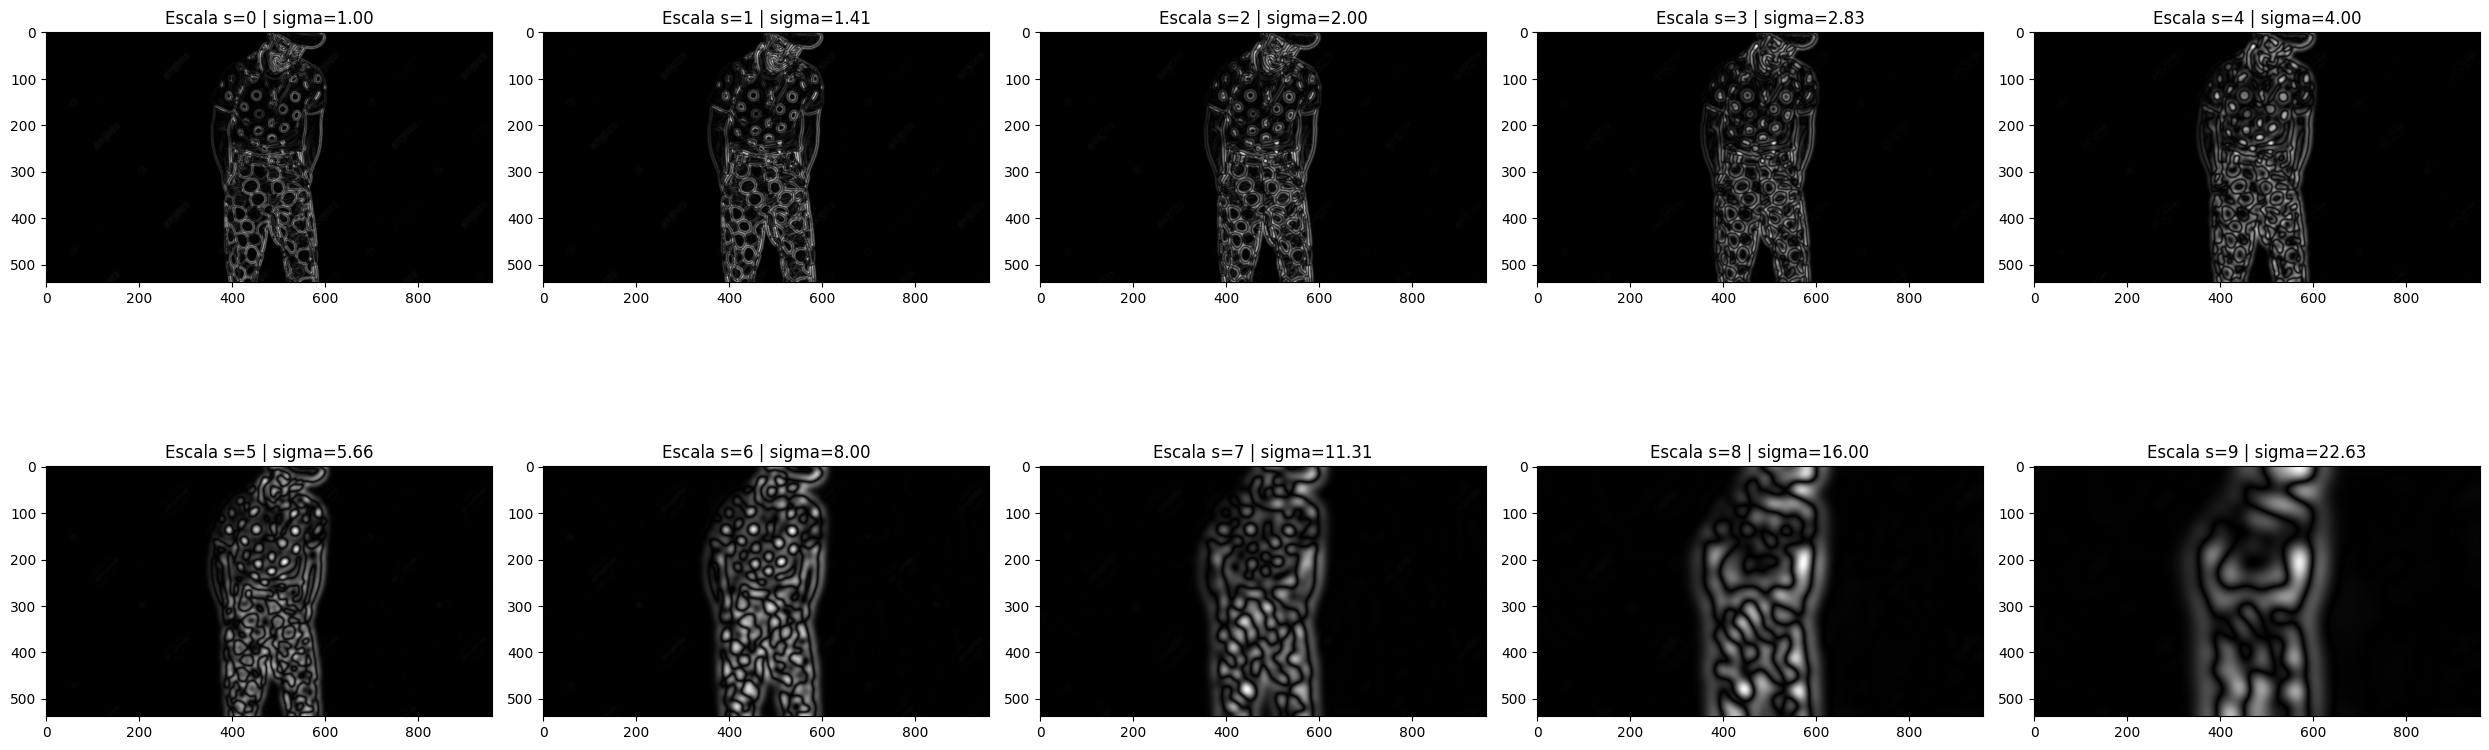

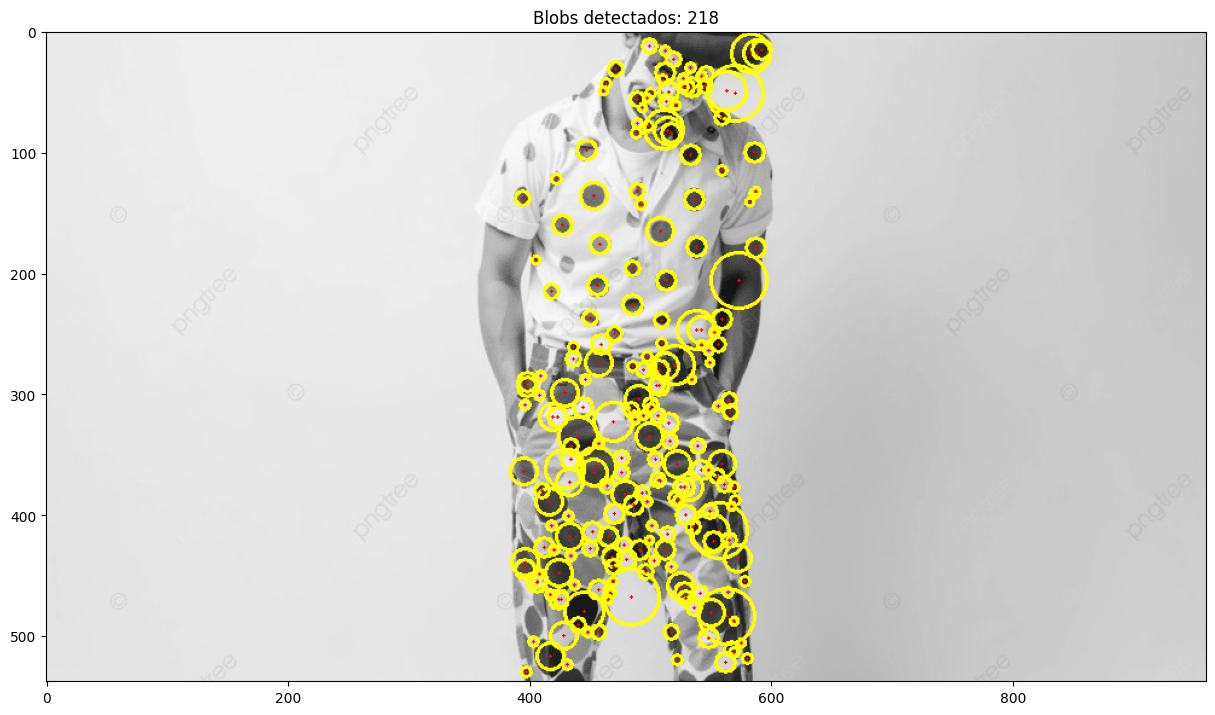

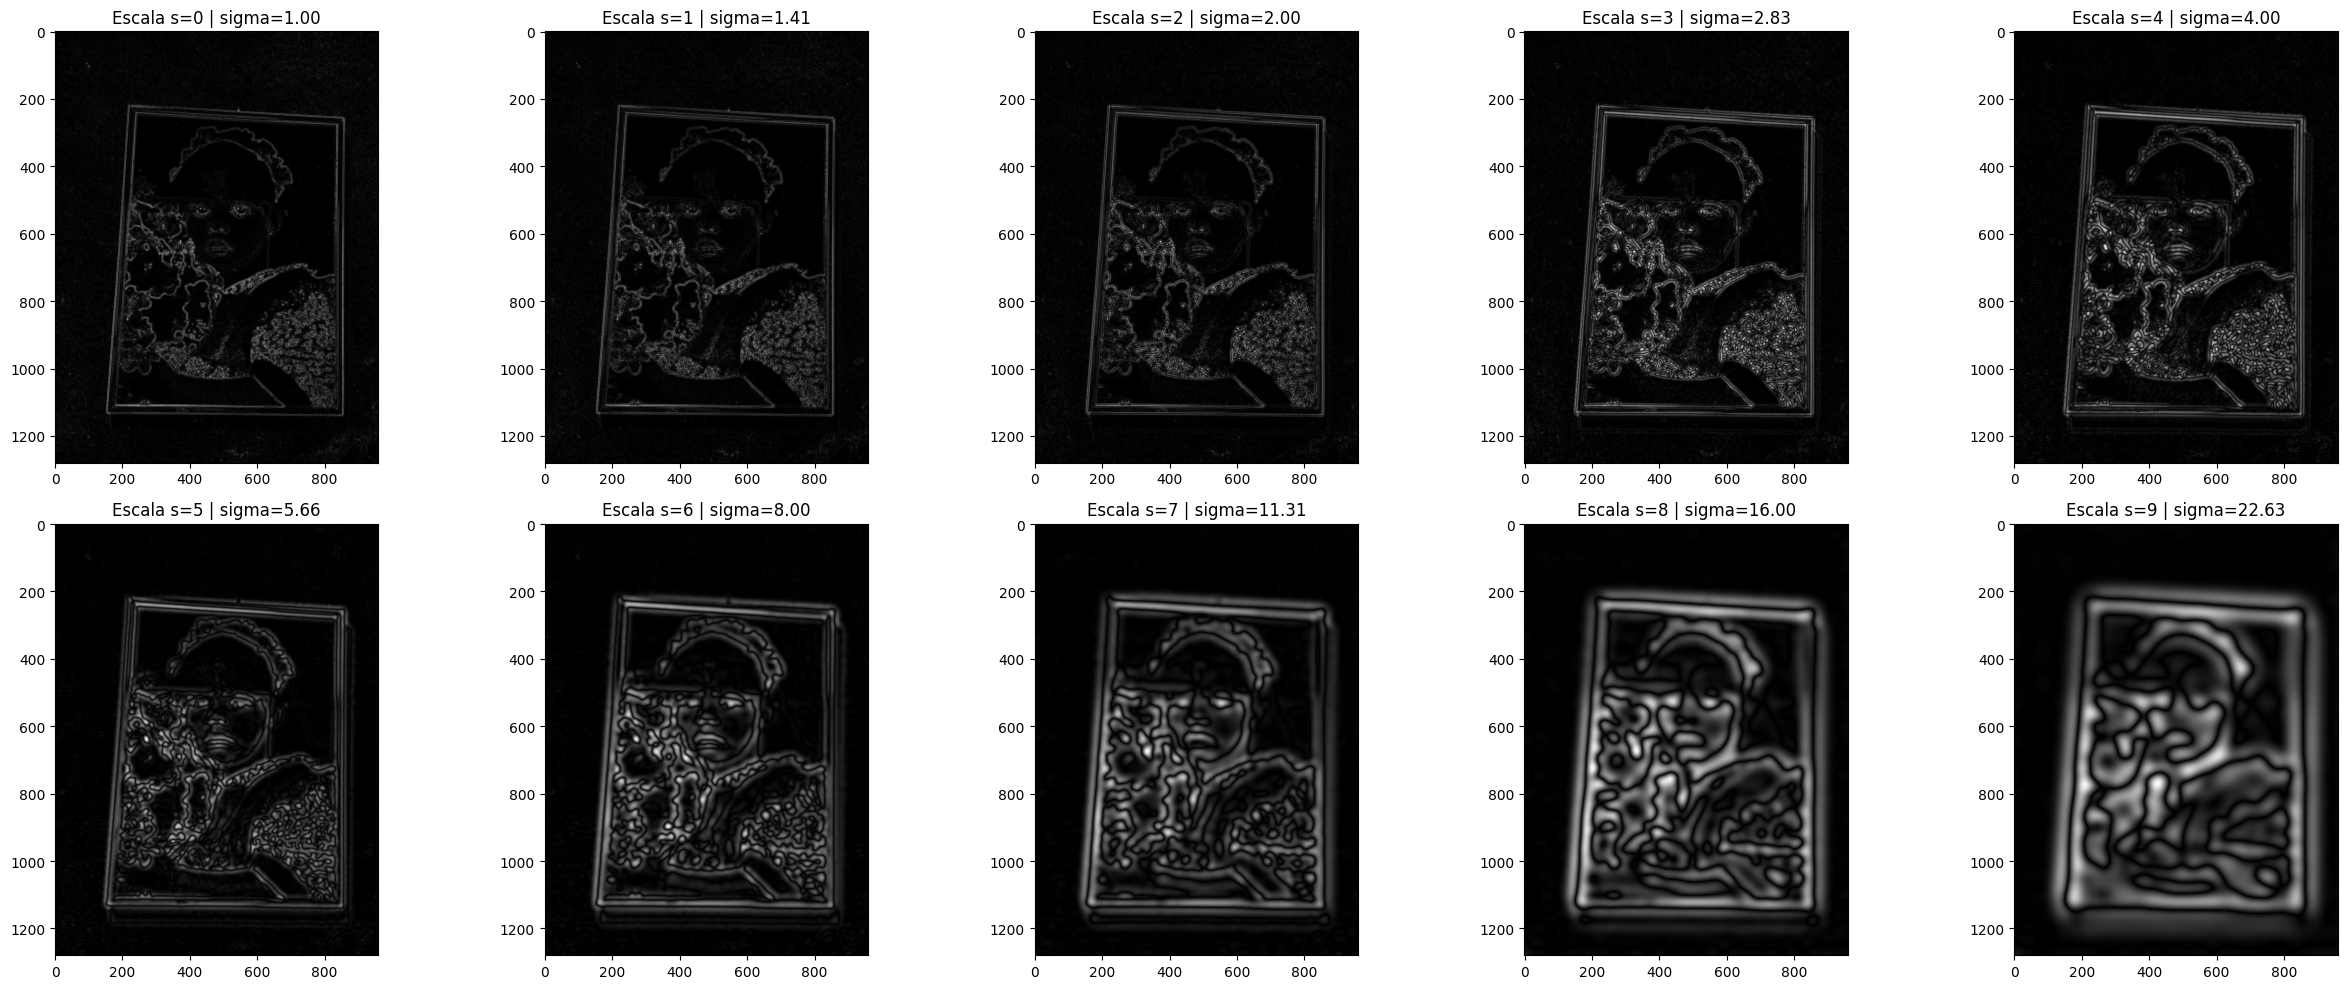

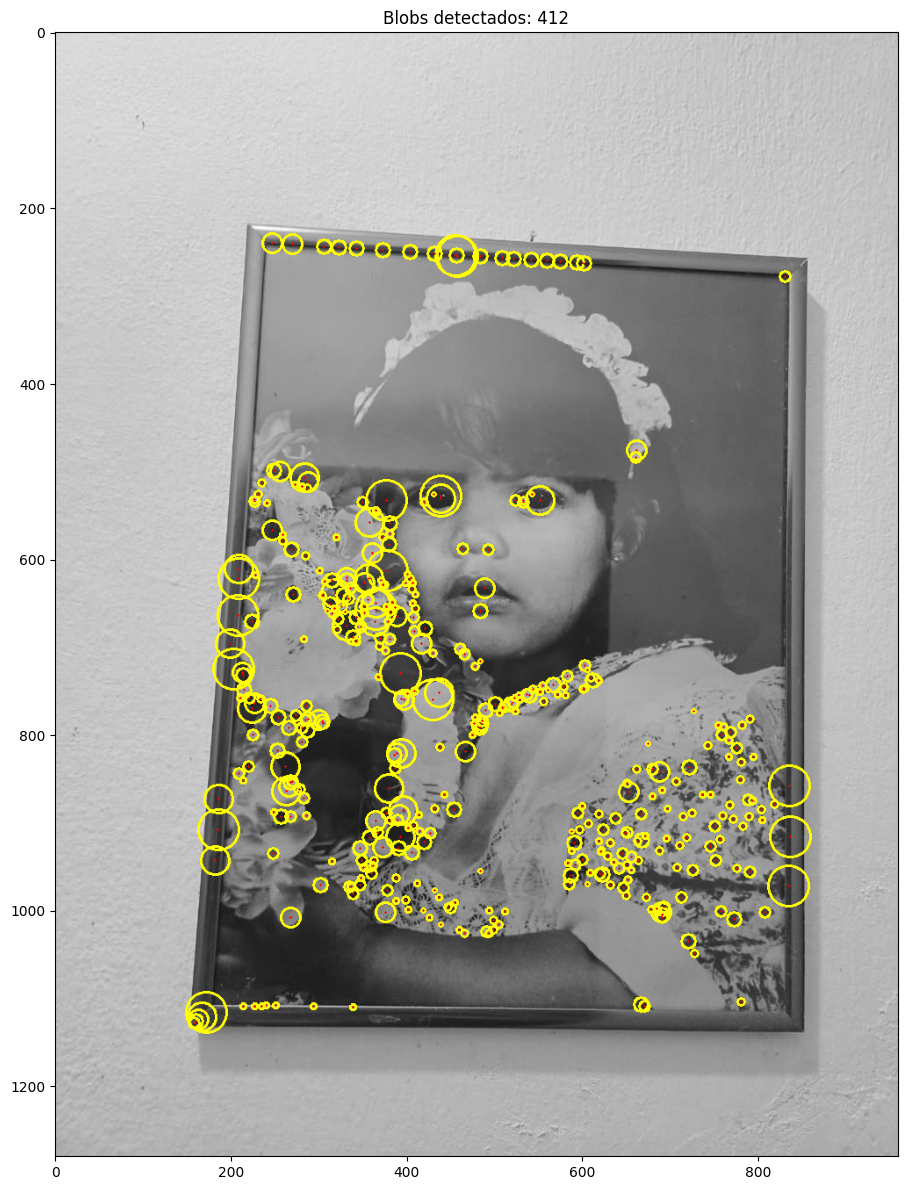

In [53]:
def blob_detector_log(
    image_path: str,
    sigma0: float = 1.0,
    k: float = np.sqrt(2),
    s_size: int = 10,
    threshold_rel: float = 0.5,
    show_scala_space: bool = False
):
    img = cv.imread(image_path, cv.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError("Could not load image")

    h, w = img.shape
    img_f = img.astype(np.float32) / 255.0

    scale_space = []
    sigmas = []
    for s in range(s_size):
        sigma_s = sigma0 * (k**s)
        sigmas.append(sigma_s)

        blur = cv.GaussianBlur(img_f, (0, 0), sigma_s)
        log = cv.Laplacian(blur, cv.CV_64F, ksize=5)
        response = (sigma_s**2) * np.abs(log)
        scale_space.append(response)

    scale_space = np.stack(scale_space, axis=0)

    threshold = threshold_rel * float(scale_space.max())
    detected_blobs = []
    for s in range(1, s_size - 1):
        for y in range(1, h - 1):
            for x in range(1, w - 1):
                pixel = scale_space[s, y, x]
                neighbors = scale_space[s - 1 : s + 2, y - 1 : y + 2, x - 1 : x + 2]
                
                if pixel >= neighbors.max() and pixel > threshold:
                    radius = np.sqrt(2) * sigmas[s]
                    detected_blobs.append((x, y, radius))

    detected_blobs.sort(key=lambda b: b[2], reverse=True)
    output = cv.cvtColor(img, cv.COLOR_GRAY2BGR)

    for x, y, r in detected_blobs:
        radius = max(1, int(round(r)))
        cv.circle(output, (int(x), int(y)), radius, (0, 255, 255), 2)
        cv.circle(output, (int(x), int(y)), 1, (0, 0, 255), -1)

    output_rgb = cv.cvtColor(output, cv.COLOR_BGR2RGB)

    if show_scala_space:    
        display_images = []
        display_titles = []
        for i in range(s_size):
            disp = cv.normalize(scale_space[i], np.empty_like(scale_space[i]), 0, 255, cv.NORM_MINMAX).astype(np.uint8)
            display_images.append(disp)
            display_titles.append(f"Escala s={i} | sigma={sigmas[i]:.2f}")

        show_images(*display_images, titles=display_titles, columns=5)

    return detected_blobs, output_rgb

blobs, output = blob_detector_log("images/clown.png", show_scala_space=True)
show_images(output, titles=[f"Blobs detectados: {len(blobs)}"], scale=12)

blobs, output = blob_detector_log("images/poster.jpeg", show_scala_space=True)
show_images(output, titles=[f"Blobs detectados: {len(blobs)}"], scale=12)